In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load NSL-KDD dataset

In [2]:
df = pd.read_csv("NSL-KDD/KDDTrain+.txt")
df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


### Adding column names

In [3]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack', 'level'
]

df.columns = columns
df.head(2)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.0,0.60,0.88,0.0,0.0,0.0,0.0,0.0,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.1,0.05,0.00,0.0,1.0,1.0,0.0,0.0,neptune,19


In [4]:
# Verify if we have null values
nulls = df.isnull().sum().sum()

# Check for duplicates
dups = df.duplicated().sum()

print(nulls, dups)

0 0


### Listing all categorical values

In [5]:
cat_columns = df.select_dtypes(include=['object']).columns.tolist()
print(cat_columns)

['protocol_type', 'service', 'flag', 'attack']


# Data Analysis

### Categorical Values Analysis

In [6]:
df.protocol_type.value_counts()

protocol_type
tcp     102688
udp      14993
icmp      8291
Name: count, dtype: int64

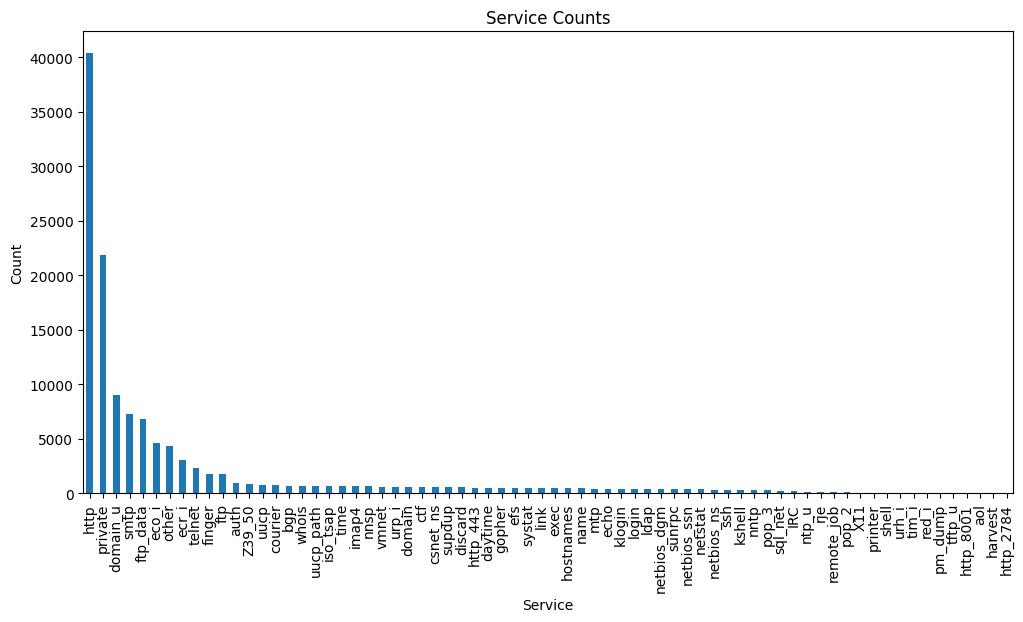

In [7]:
plt.figure(figsize=(12, 6))
df.service.value_counts().plot(kind='bar')
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Service Counts')
plt.xticks()
plt.show()


#### Top services : Http, rpivate, domain_u, smtp, ftp, other..

In [8]:
df.flag.value_counts()

flag
SF        74944
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64

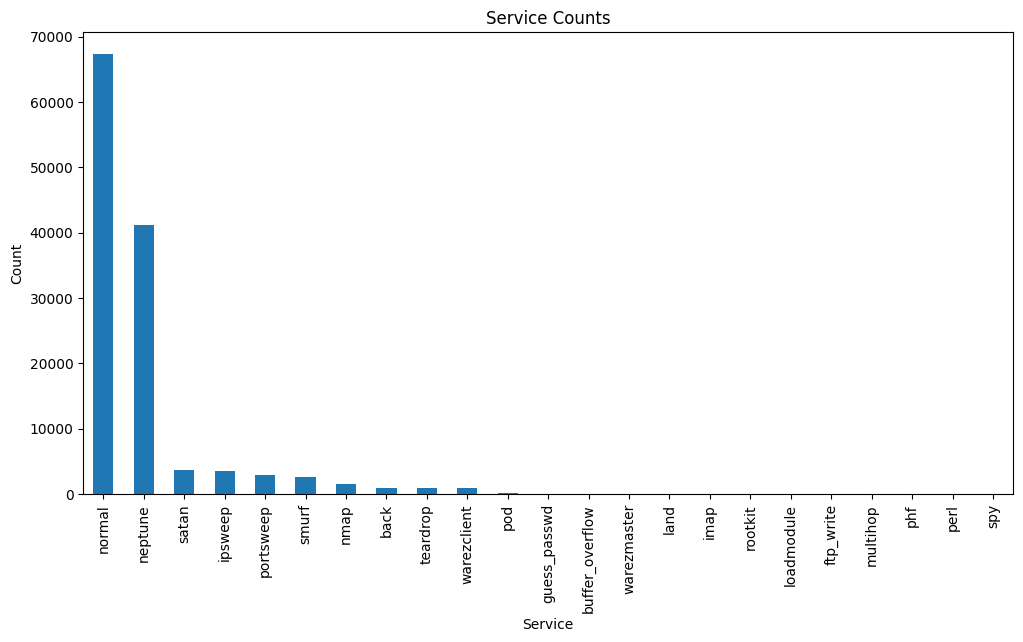

In [9]:
plt.figure(figsize=(12, 6))
df.attack.value_counts().plot(kind='bar')
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Service Counts')
plt.xticks()
plt.show()


#### I think here we should convert attach column to binary labels = 'normal' or 'attack'

In [10]:
df['attack'] = df['attack'].apply(lambda x: 'normal' if x=='normal' else 'attack')
df.attack.value_counts()

attack
normal    67342
attack    58630
Name: count, dtype: int64

### Viz Feature Distributions

array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'src_bytes'}>,
        <Axes: title={'center': 'dst_bytes'}>,
        <Axes: title={'center': 'land'}>,
        <Axes: title={'center': 'wrong_fragment'}>,
        <Axes: title={'center': 'urgent'}>],
       [<Axes: title={'center': 'hot'}>,
        <Axes: title={'center': 'num_failed_logins'}>,
        <Axes: title={'center': 'logged_in'}>,
        <Axes: title={'center': 'num_compromised'}>,
        <Axes: title={'center': 'root_shell'}>,
        <Axes: title={'center': 'su_attempted'}>],
       [<Axes: title={'center': 'num_root'}>,
        <Axes: title={'center': 'num_file_creations'}>,
        <Axes: title={'center': 'num_shells'}>,
        <Axes: title={'center': 'num_access_files'}>,
        <Axes: title={'center': 'num_outbound_cmds'}>,
        <Axes: title={'center': 'is_host_login'}>],
       [<Axes: title={'center': 'is_guest_login'}>,
        <Axes: title={'center': 'count'}>,
        <Axes: title

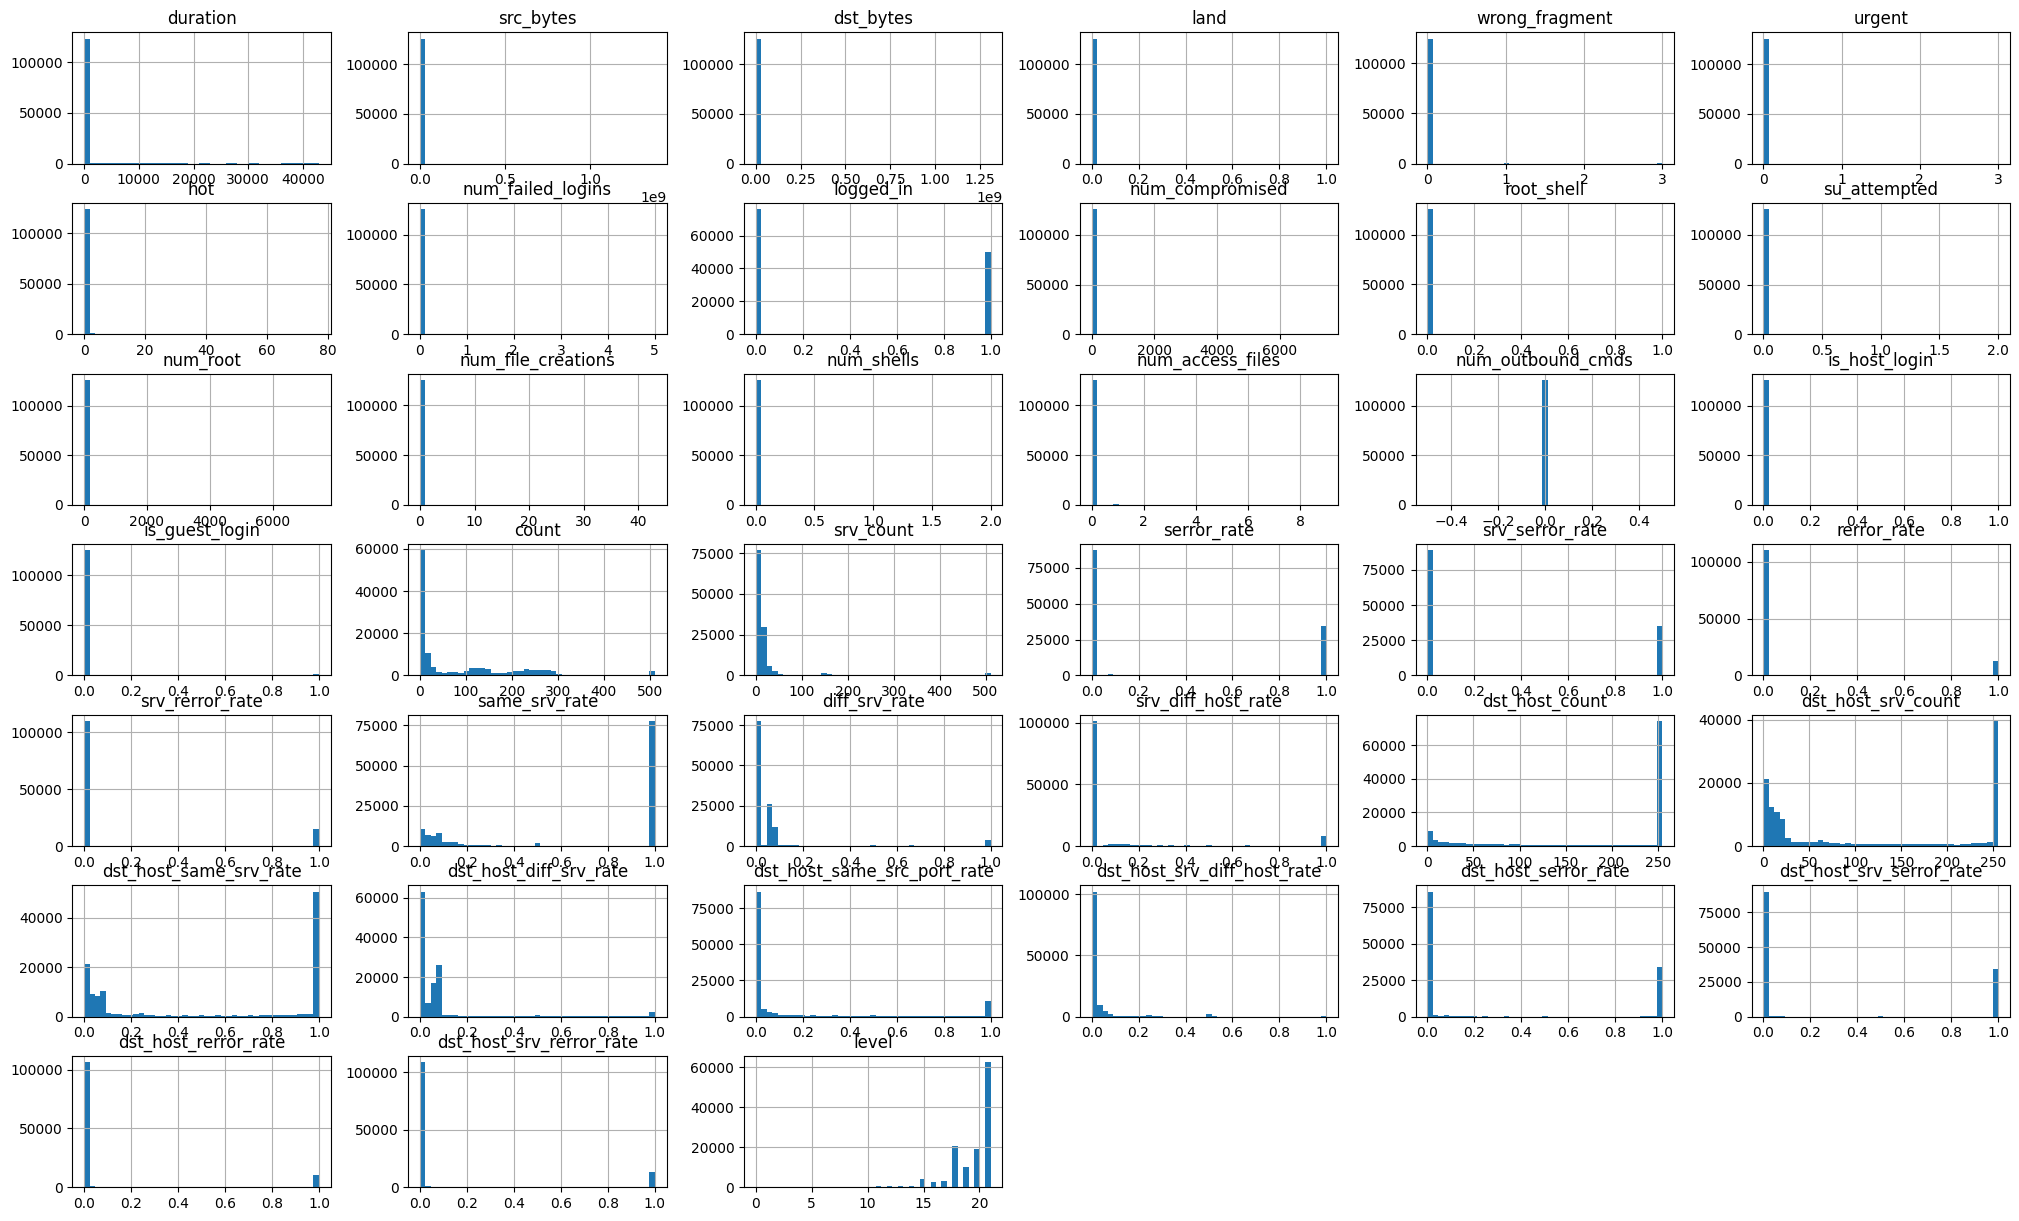

In [11]:
import warnings
warnings.filterwarnings('ignore')

df.hist(bins=43, figsize=(25,15))

### Check for outliers

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 2000x4000 with 0 Axes>

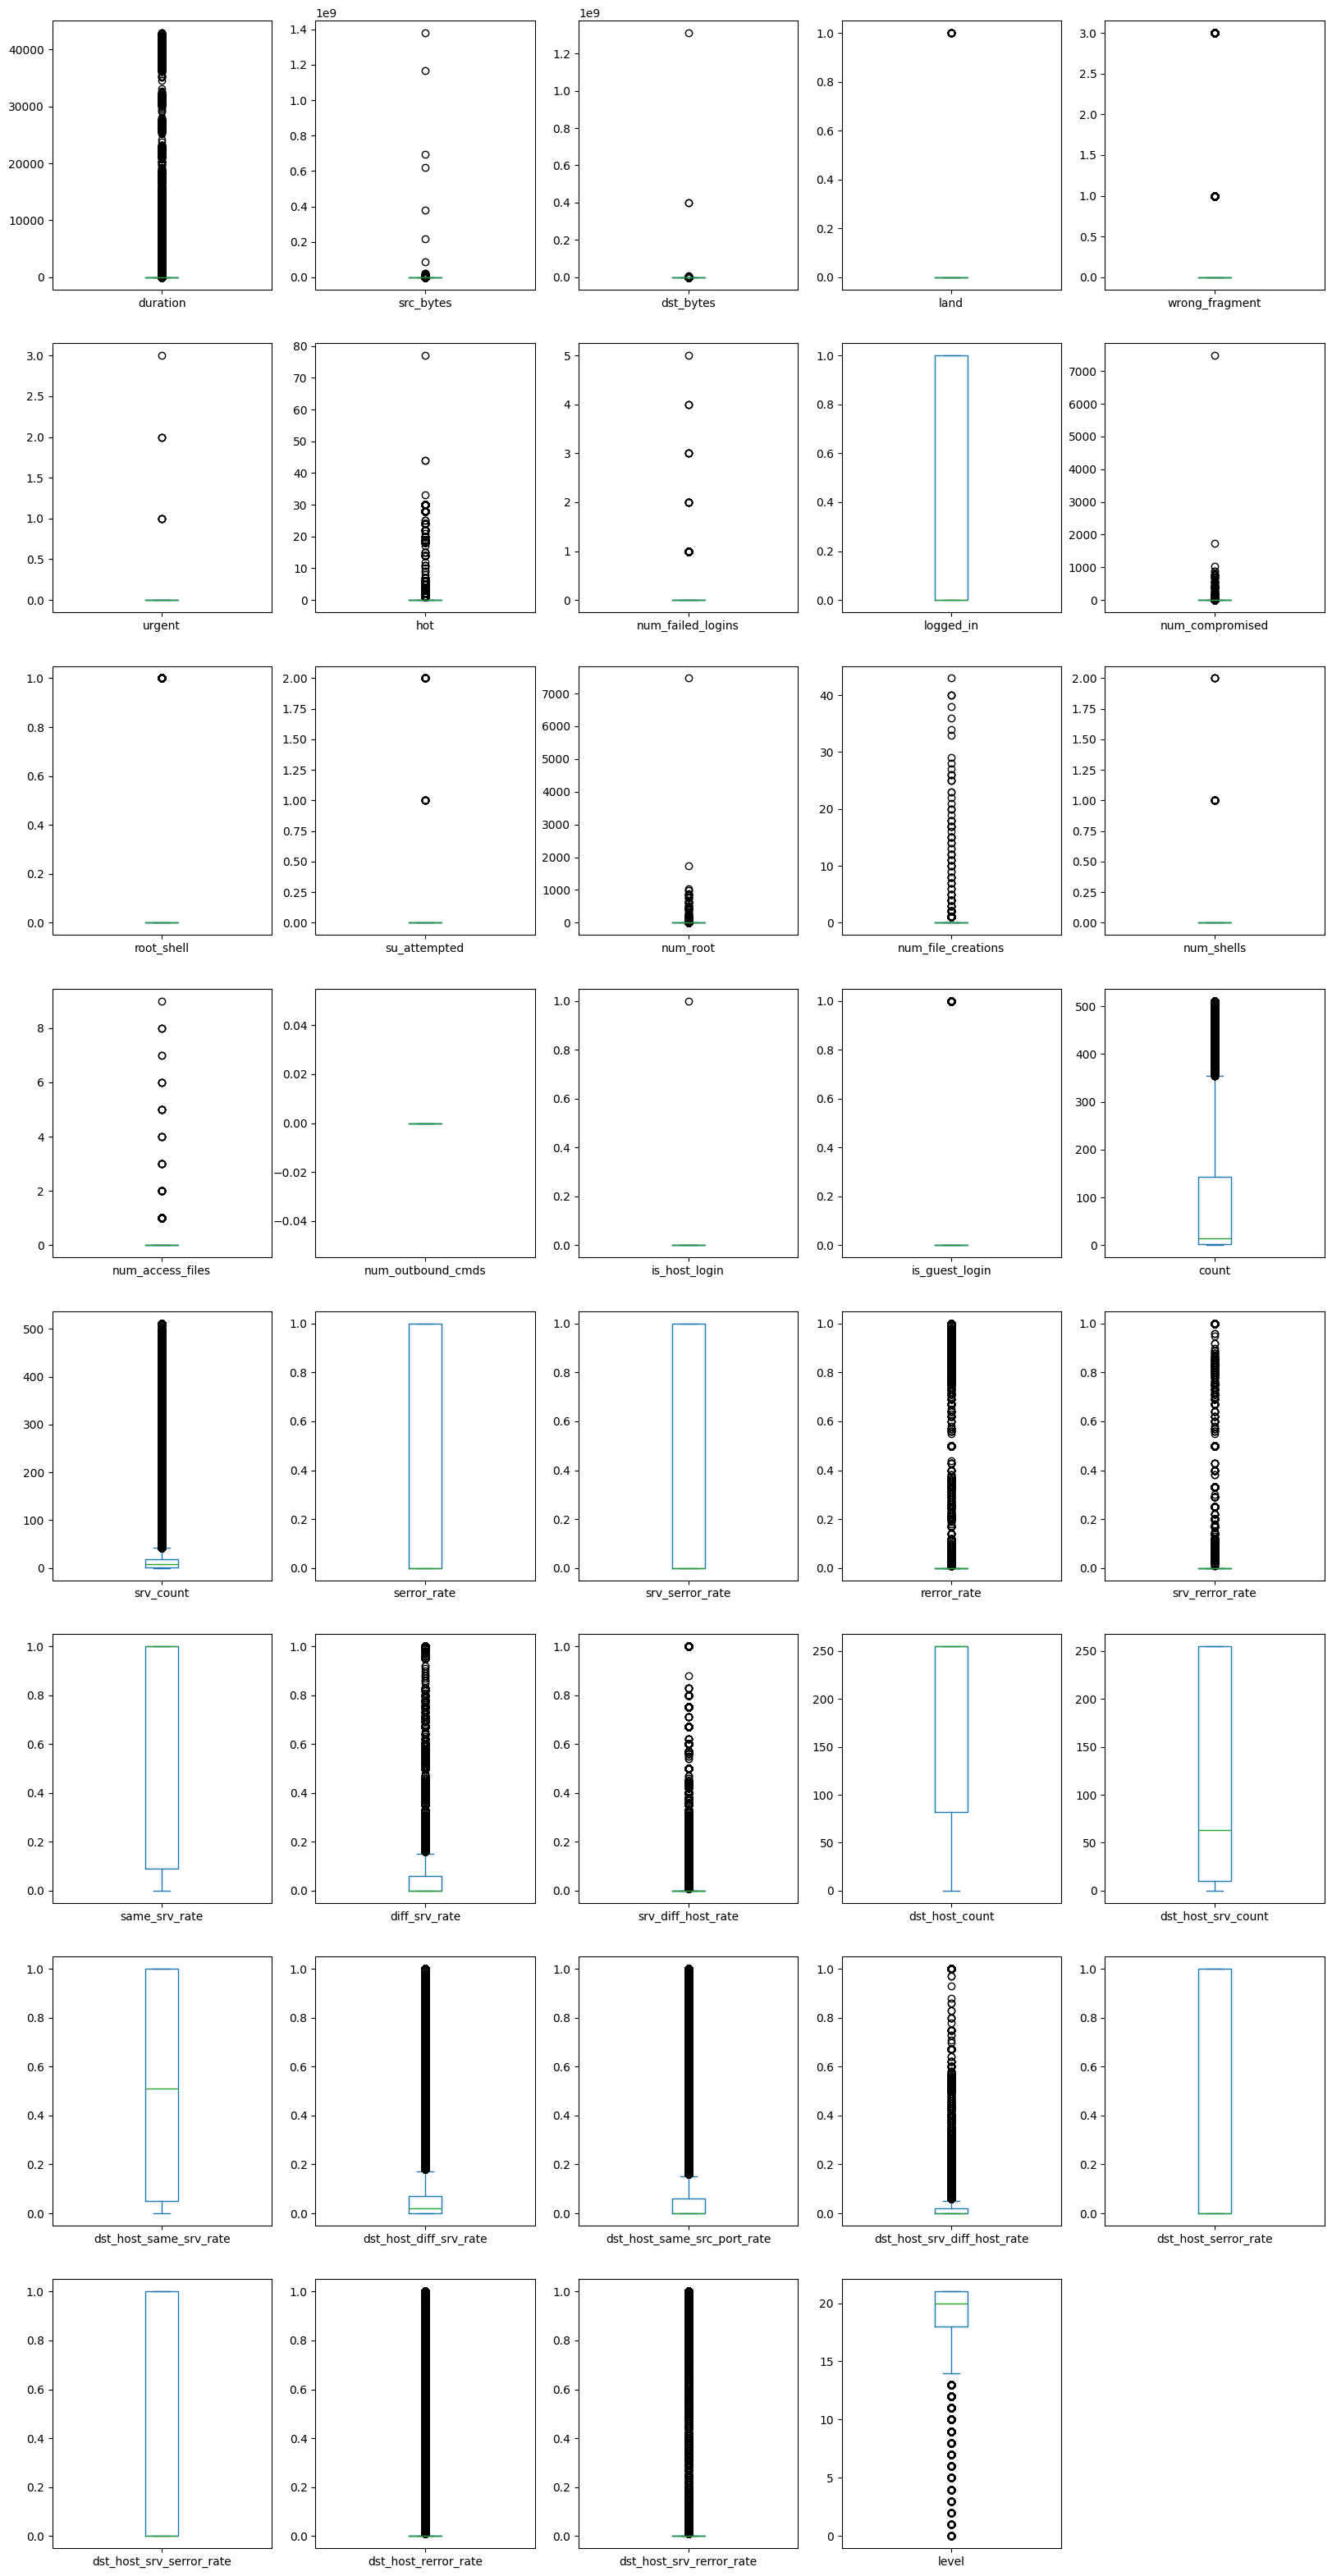

In [12]:
plt.figure(figsize=(20,40))

df.plot(kind='box', subplots=True, layout=(8,5), figsize=(20,40) )
plt.show

### Attack per Protocol Type

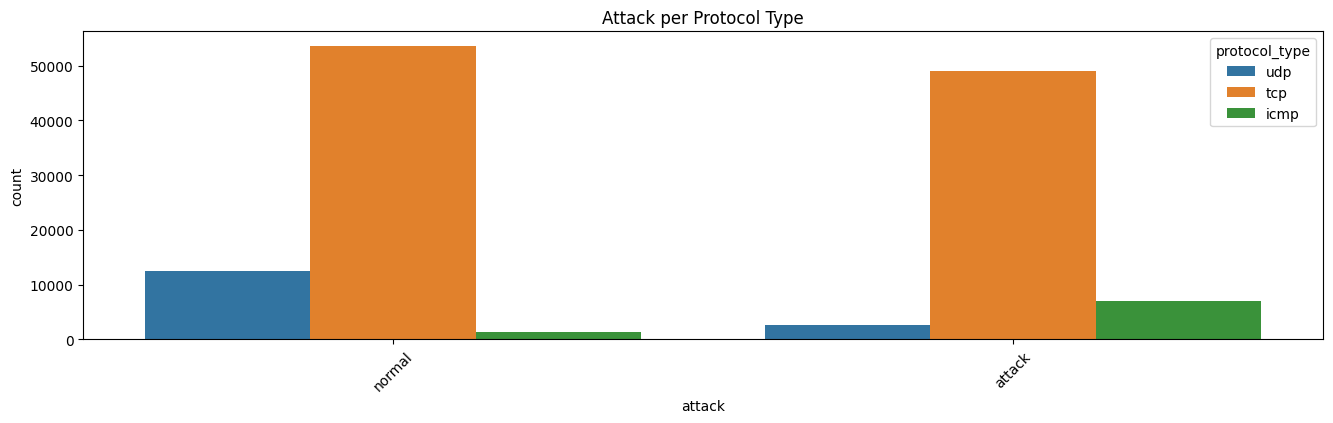

In [13]:
plt.figure(figsize=(16,4))
sns.countplot(x='attack', data=df, hue='protocol_type')
plt.xticks(rotation=45)
plt.title('Attack per Protocol Type')
plt.show()

#### I can see that TCP has the most attacks than UDP which has the least attacks. ICMP seems the protocol in which it has more attack than normal 

### It would be a great idea to see the attack distribution across network services

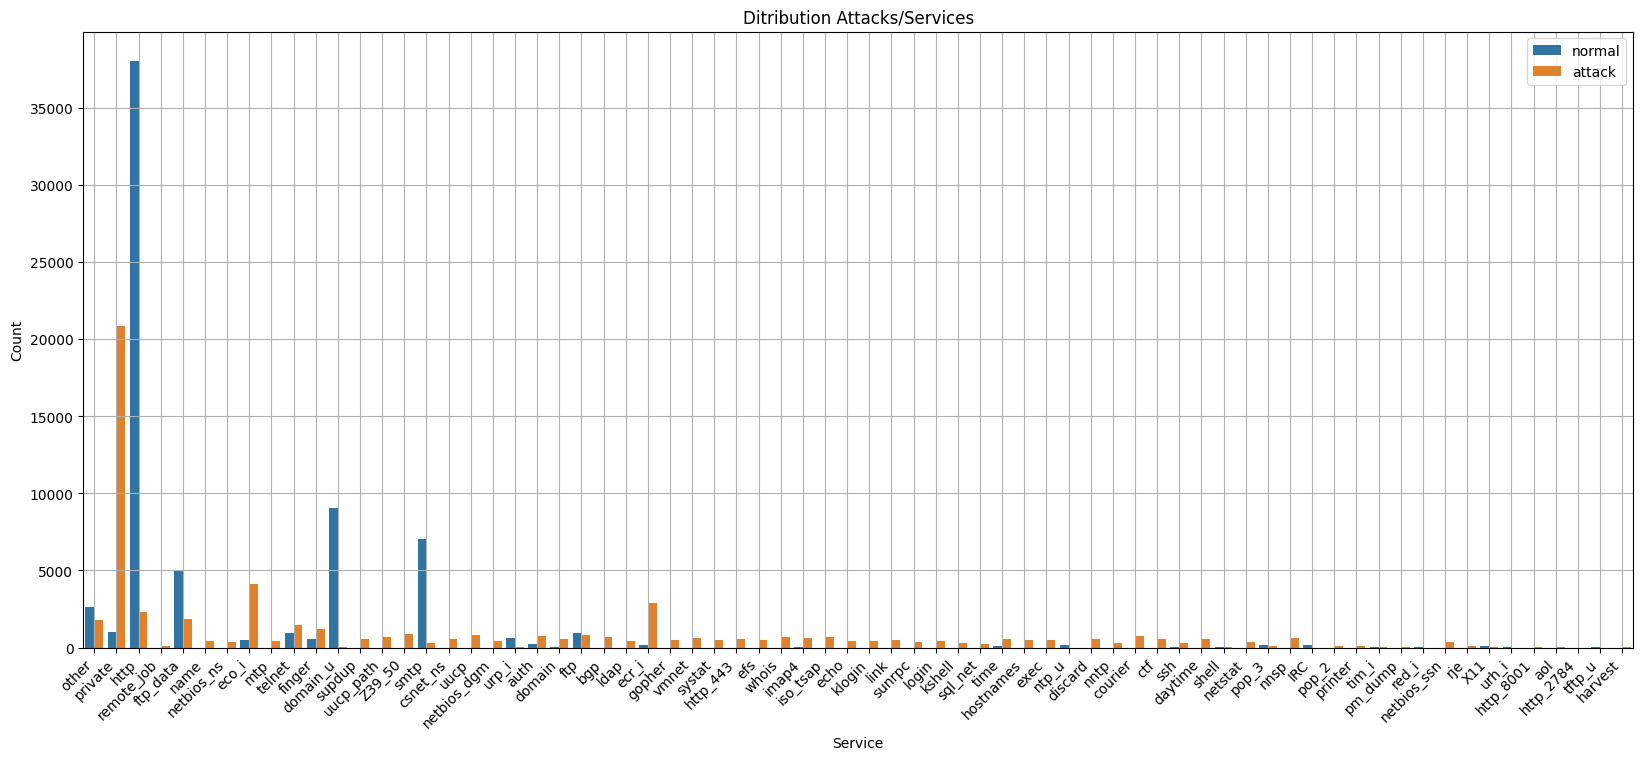

In [14]:
plt.figure(figsize=(20,8))
ax = sns.countplot(x='service', hue='attack', data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Ditribution Attacks/Services')
plt.legend()
plt.grid(True)

plt.show()

#### I need numbers to analyse this better

In [15]:
# Calculate counts and percentages as before
service_attack_counts = df.groupby(['service', 'attack']).size().reset_index(name='count')
service_totals = service_attack_counts.groupby('service')['count'].transform('sum')
service_attack_counts['percentage'] = (service_attack_counts['count'] / service_totals * 100).round(2)

# Filter for only the 'attack' rows
attack_percentages = service_attack_counts[service_attack_counts['attack'] == 'attack']

# Sort by percentage of attack descending
attack_percentages_sorted = attack_percentages.sort_values('percentage', ascending=False)

(attack_percentages_sorted[['service', 'percentage']])

# First, get the order of services sorted by 'attack' percentage
attack_order = attack_percentages_sorted['service']

# Now, pivot the table for all attack types
result = service_attack_counts.pivot(index='service', columns='attack', values='percentage')


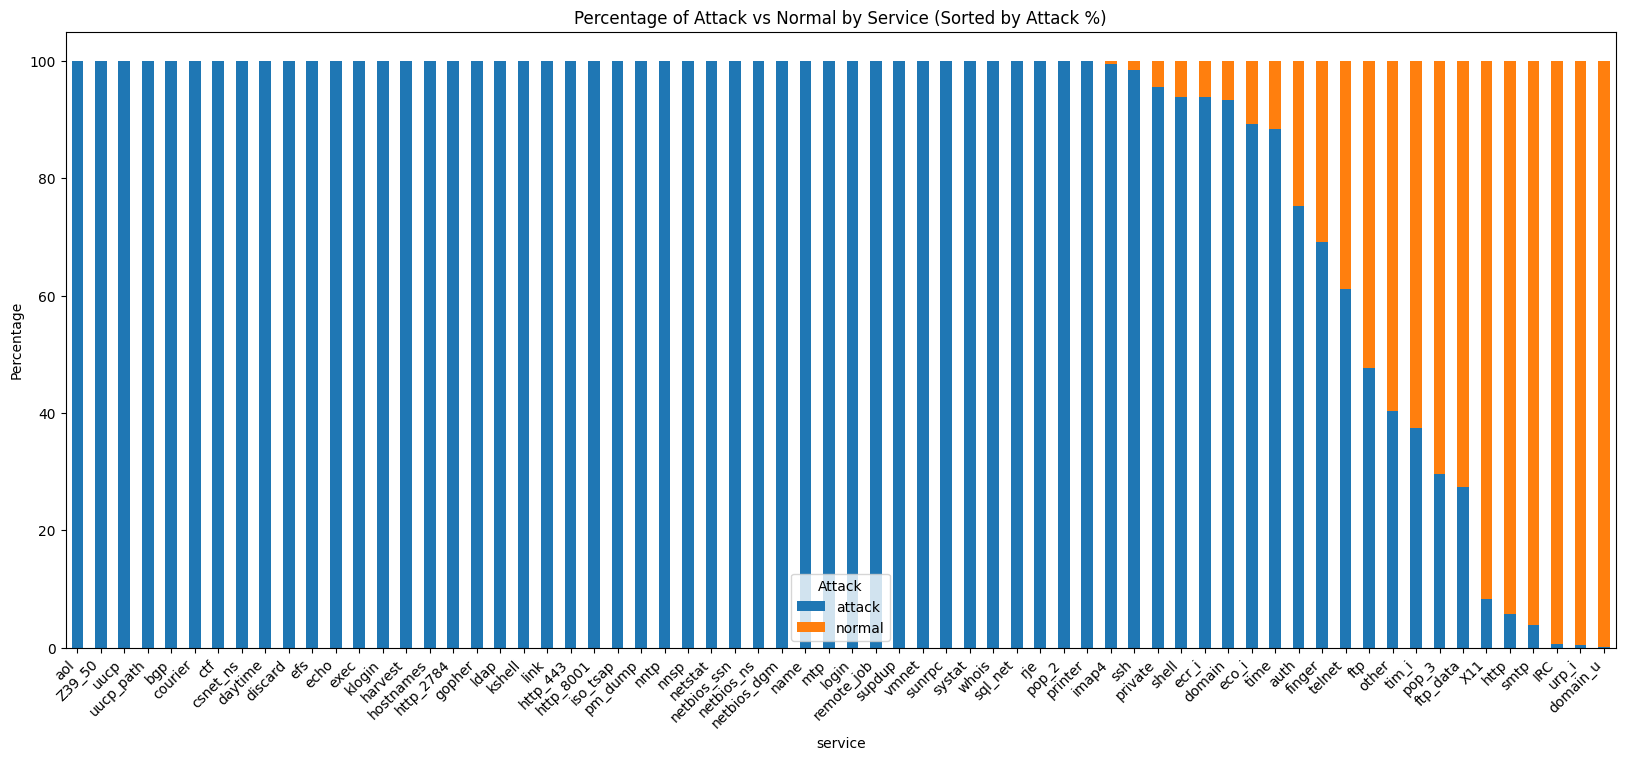

In [16]:
# If you have the pivot_df from previous step:
pivot_df = service_attack_counts.pivot(index='service', columns='attack', values='percentage')
# Reorder
pivot_df = pivot_df.loc[attack_order]

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(20,8))
plt.ylabel('Percentage')
plt.title('Percentage of Attack vs Normal by Service (Sorted by Attack %)')
plt.legend(title='Attack')
plt.xticks(rotation=45, ha='right')
plt.show()


### Connection Duration vs Flag Type

In [17]:
df.duration.dtype

dtype('int64')

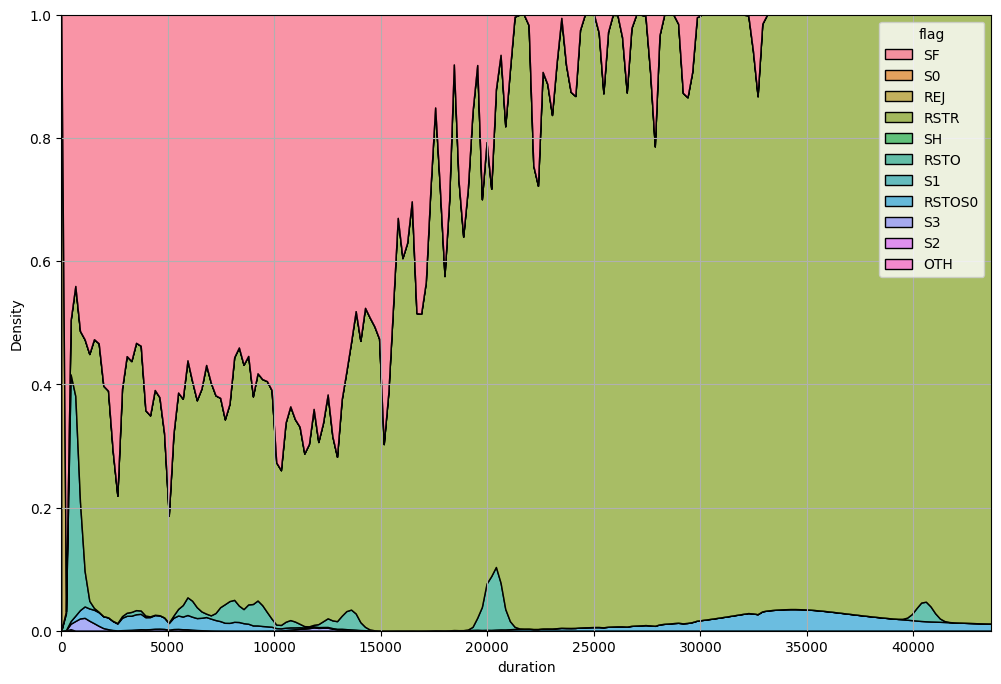

In [18]:
plt.figure(figsize=(12, 8))

sns.kdeplot(
    data=df,
    x="duration",
    hue="flag",
    multiple="fill",
    clip=(0, None),
)
plt.grid()
plt.show()


In [19]:
# reminder of df cols
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'attack', 'level'],
      dtype='object')

### Attack distribution based on Guest Login Status

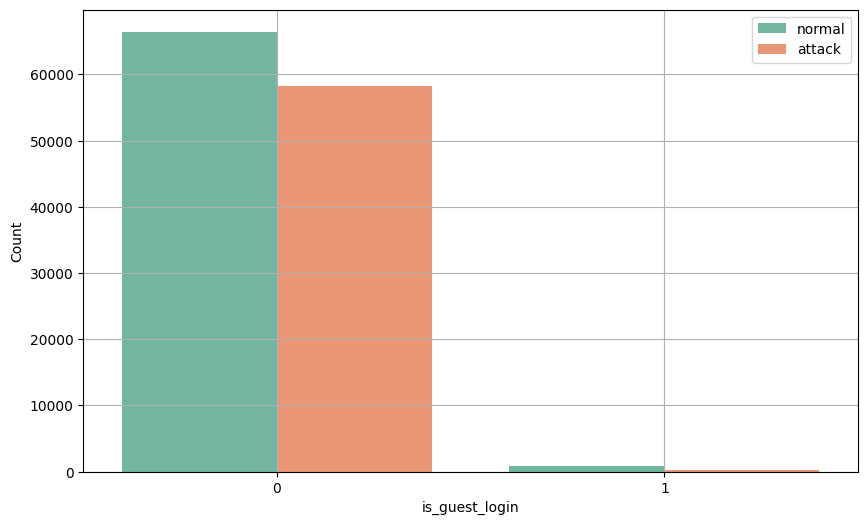

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(x="is_guest_login", hue="attack", data=df, palette='Set2')

plt.xlabel('is_guest_login')
plt.ylabel('Count')

plt.legend()
plt.grid(True)
plt.show()

# Preprocessing

In [21]:
cat_columns

['protocol_type', 'service', 'flag', 'attack']

In [22]:
from sklearn import preprocessing
le=preprocessing.LabelEncoder()
for x in cat_columns:
    df[x]=le.fit_transform(df[x])

In [23]:
df[cat_columns]

,protocol_type,service,flag,attack
0,2,44,9,1
1,1,49,5,0
2,1,24,9,1
3,1,24,9,1
4,1,49,1,0
...,...,...,...,...
125967,1,49,5,0
125968,2,49,9,1
125969,1,54,9,1
125970,1,30,5,0


# Data splitting (train/test)

In [24]:
from sklearn.model_selection import train_test_split

X=df.drop(['attack'], axis=1)
y=df['attack']

X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [25]:
train_index=X_train.columns
train_index

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'level'],
      dtype='object')

# Feature Engineering

In [26]:
from sklearn.feature_selection import mutual_info_classif

# see how much a feature can tell about the target
mutual_info = mutual_info_classif(X_train, y_train)
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Mutual_Info': mutual_info

})

mi_df = mi_df.sort_values(by="Mutual_Info", ascending=False)
mi_df.head(10)


,Feature,Mutual_Info
4,src_bytes,0.565640
2,service,0.467905
5,dst_bytes,0.442607
3,flag,0.368614
28,same_srv_rate,0.366398
29,diff_srv_rate,0.359841
32,dst_host_srv_count,0.337276
33,dst_host_same_srv_rate,0.312574
11,logged_in,0.290882
34,dst_host_diff_srv_rate,0.286521


In [27]:
print(type(mi_df))
#We should convert this to pandas Series for easier handling

mutual_info=pd.Series(mutual_info)

#Setting index
mutual_info.index=train_index

<class 'pandas.core.frame.DataFrame'>


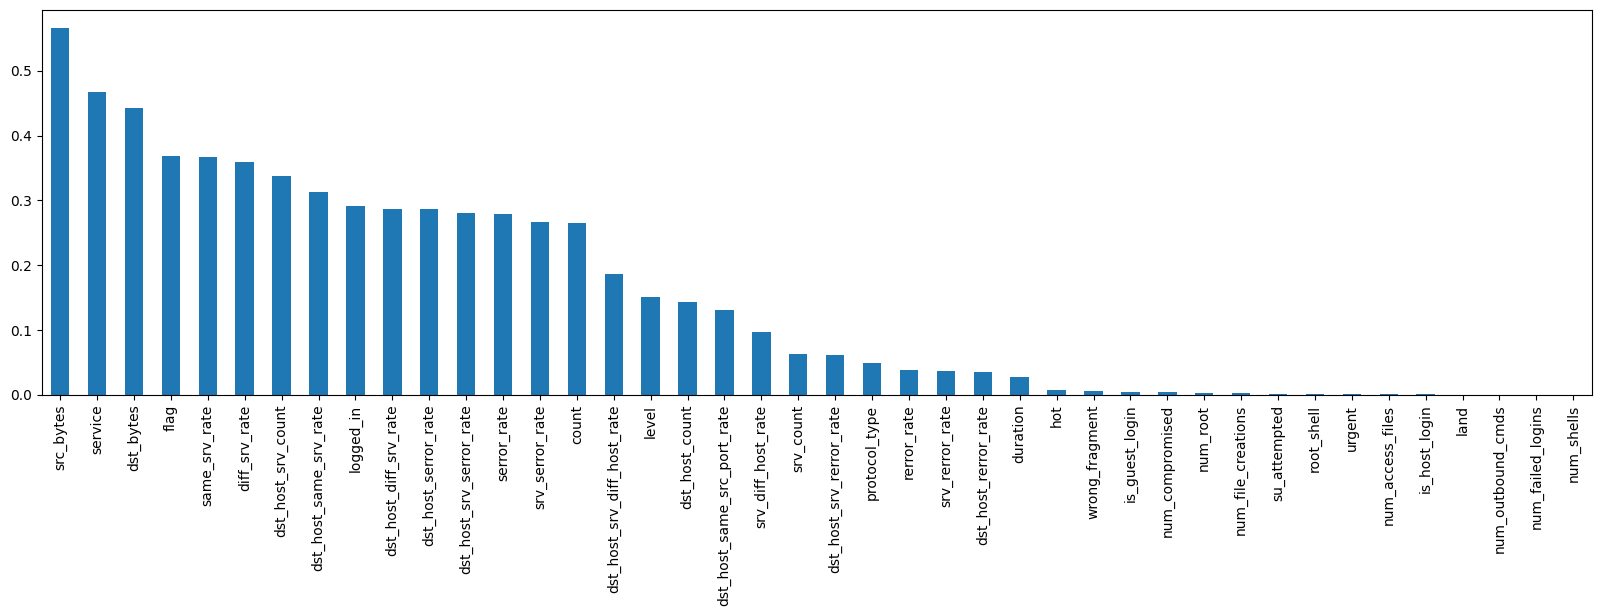

In [28]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 5));

# Feature Selection

In [29]:
from sklearn.feature_selection import SelectKBest

#Get to 30 features
select_features = SelectKBest(mutual_info_classif, k=30)

#Fit the selector to the training data
select_features.fit(X_train, y_train)

,score_func,<function mut...x7df80611efc0>
,k,30


In [30]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

#Fit the scaler on training data and transform it
X_train=scaler.fit_transform(X_train)

#Trasform test data
X_test=scaler.transform(X_test)

# Model Building

In [31]:
from sklearn.linear_model import LogisticRegression #Our base model
from xgboost import XGBClassifier

In [39]:
# Init xgboost
XGBoost_model=XGBClassifier(random_state=42)

#Init Logistic reg
Logistic_model=LogisticRegression(random_state=42)

In [40]:
#train logistic reg
Logistic=Logistic_model.fit(X_train, y_train)

#train xgboost
XGBoost=XGBoost_model.fit(X_train, y_train)

In [41]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred=model.predict(X_train)
    y_pred=model.predict(X_test)

    print('Test Set')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

    print('Train set')
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [42]:
#Evaluate Logistic Reg
eval_metric(Logistic_model, X_train, y_train, X_test, y_test)

Test Set
[[11564   245]
 [  343 13043]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     11809
           1       0.98      0.97      0.98     13386

    accuracy                           0.98     25195
   macro avg       0.98      0.98      0.98     25195
weighted avg       0.98      0.98      0.98     25195


Train set
[[45934   887]
 [ 1316 52640]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     46821
           1       0.98      0.98      0.98     53956

    accuracy                           0.98    100777
   macro avg       0.98      0.98      0.98    100777
weighted avg       0.98      0.98      0.98    100777



In [43]:
#Eval XGBoost
eval_metric(XGBoost_model, X_train, y_train, X_test, y_test)

Test Set
[[11808     1]
 [    5 13381]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11809
           1       1.00      1.00      1.00     13386

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


Train set
[[46821     0]
 [    0 53956]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     46821
           1       1.00      1.00      1.00     53956

    accuracy                           1.00    100777
   macro avg       1.00      1.00      1.00    100777
weighted avg       1.00      1.00      1.00    100777



# Hyperparamater Tuning

In [44]:
param_grid={
    'n_estimators': [50,64,100,128], #number of trees
    'max_depth': [2,3,4,5,6,7,8,9,10], #Max depth?
    'learning_rate' : [0.01, 0, 0.03, 0.05, 0.1],
    'subsample': [0.5, 0.8],
    'colsample_bytree': [0.5, 0.8]
}

In [45]:
from sklearn.model_selection import GridSearchCV

XGB_model = XGBClassifier(random_state=42)

XGB_grid_model=GridSearchCV(
    estimator=XGB_model,
    param_grid=param_grid,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
).fit(X_train, y_train)

In [46]:
XGB_grid_model.best_score_

np.float64(0.9995922132945718)

In [47]:
XGB_grid_model.best_params_

{'colsample_bytree': 0.5,
 'learning_rate': 0.1,
 'max_depth': 10,
 'n_estimators': 100,
 'subsample': 0.8}

In [48]:
XGB_model=XGBClassifier(
    colsample_bytree=0.5,
    learning_rate=0.1,
    max_depth=10,
    n_estimators=100,
    subsample=0.8
)

XGB_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Calculate the ROC AUX how well the model seperates the classes

In [49]:
y_pred=XGB_model.predict(X_test)

#predict class probabilities on the test set
y_pred_proba=XGB_model.predict_proba(X_test)

#Calculate f1 score
xgb_f1=f1_score(y_test, y_pred)

#recall
xgb_recall=recall_score(y_test, y_pred)

#ROC AUC
xgb_auc=roc_auc_score(y_test, y_pred_proba[:,1])

In [50]:
xgb_auc

0.9999994369770948

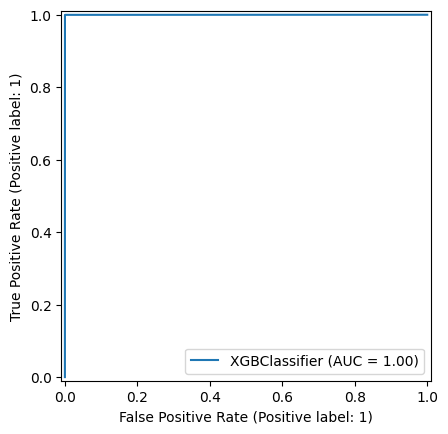

In [51]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(XGB_model, X_test, y_test)

In [52]:
# Evaluate the final tuned XGBoost model on both training and test sets
eval_metric(XGB_model, X_train, y_train, X_test, y_test)

Test Set
[[11807     2]
 [    4 13382]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11809
           1       1.00      1.00      1.00     13386

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


Train set
[[46820     1]
 [    2 53954]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     46821
           1       1.00      1.00      1.00     53956

    accuracy                           1.00    100777
   macro avg       1.00      1.00      1.00    100777
weighted avg       1.00      1.00      1.00    100777



# Feature Importance

In [55]:
model = XGB_model

# Get feature importances from the model
model.feature_importances_

columns = [col for col in columns if col != 'attack']

# Create a DataFrame to display feature importances with feature names as index
feats = pd.DataFrame(
    index=X[columns].columns,
    data=model.feature_importances_,
    columns=['XGB_importance']
)


# Sort the features by importance in descending order
ada_imp_feats = feats.sort_values("XGB_importance", ascending=False)

# Display the sorted feature importances
ada_imp_feats

,XGB_importance
dst_bytes,0.217805
src_bytes,0.140381
flag,0.107002
diff_srv_rate,0.104318
protocol_type,0.051409
count,0.050882
dst_host_same_srv_rate,0.031129
hot,0.027584
level,0.027317
srv_serror_rate,0.024792
